In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!pip install tensorflow

In [3]:
import os, shutil
import PIL
import tensorflow as tf
from collections import Counter

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.metrics import CategoricalAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives, AUC, Precision, Recall
from tensorflow.keras.losses import CategoricalCrossentropy as CCE
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [7]:
df = pd.read_csv('/content/drive/MyDrive/car parts 50/car parts.csv')
df.head()

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train


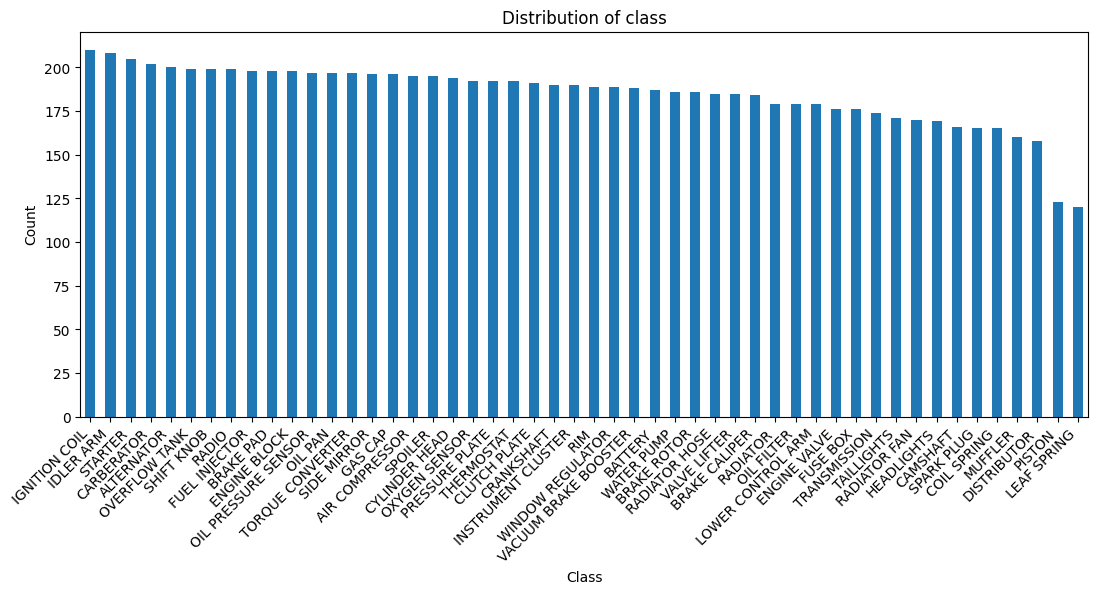

In [8]:
plt.figure(figsize=(13,5))
df['labels'].value_counts().plot(kind='bar')
plt.title('Distribution of class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout
plt.show()




In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import gzip
import torch
import glob
import os

In [10]:
dir = '/content/drive/MyDrive/car parts 50/'

In [11]:
train_path = os.path.join(dir, 'train')
test_path = os.path.join(dir, 'test')
valid_path = os.path.join(dir, 'valid')

paths = [train_path, test_path, valid_path]
names = ['train', 'test', 'valid']

limiter = float('inf') # Set a high limit or define a specific number

df_train = pd.DataFrame()
df_test = pd.DataFrame()
df_valid = pd.DataFrame()

for i in range(3):
  path = paths[i]
  name = names[i]
  klasses = os.listdir(path) # Changed 'class' to 'klasses' as 'class' is a reserved keyword
  file_paths = []
  labels = []

  for klass in klasses: # Added colon and used 'klasses'
    class_path = os.path.join(path, klass)
    file_list = os.listdir(class_path)

    if len(file_list) > limiter:
      file_list = np.random.choice(file_list, int(limiter), replace=False) # Ensure limiter is int for np.random.choice

    for f in file_list:
      file_path = os.path.join(class_path, f)
      file_paths.append(file_path)
      labels.append(klass)

  fseries = pd.Series(file_paths, name='file_path')
  lseries = pd.Series(labels, name='labels')

  if name == 'train':
    df_train = pd.concat([fseries, lseries], axis=1)
  elif name == 'test':
    df_test = pd.concat([fseries, lseries], axis=1)
  else:
    df_valid = pd.concat([fseries, lseries], axis=1)

num_of_class = len(klasses) # Changed 'class' to 'klasses'

print(f'test_df shape: {df_test.shape}')
print(f'train_df shape: {df_train.shape}')
print(f'valid_df shape: {df_valid.shape}')

train_balance = df_train['labels'].value_counts() # Changed 'train_df' to 'df_train'

print(f'train_set has {num_of_class} class, class balance is: {train_balance}')

test_df shape: (250, 2)
train_df shape: (8739, 2)
valid_df shape: (250, 2)
train_set has 50 class, class balance is: labels
IGNITION COIL           200
IDLER ARM               198
STARTER                 195
CARBERATOR              192
ALTERNATOR              190
RADIO                   189
OVERFLOW TANK           189
SHIFT KNOB              189
ENGINE BLOCK            188
FUEL INJECTOR           188
BRAKE PAD               188
OIL PRESSURE SENSOR     187
TORQUE CONVERTER        187
OIL PAN                 187
SIDE MIRROR             186
GAS CAP                 186
AIR COMPRESSOR          185
SPOILER                 185
CYLINDER HEAD           184
OXYGEN SENSOR           182
PRESSURE PLATE          182
THERMOSTAT              182
CLUTCH PLATE            181
CRANKSHAFT              180
INSTRUMENT CLUSTER      180
RIM                     179
WINDOW REGULATOR        179
VACUUM BRAKE BOOSTER    178
BATTERY                 177
WATER PUMP              176
BRAKE ROTOR             176
VALVE LI

In [21]:
print(f"Listing contents of: {train_path}")
!ls -R "{train_path}" | head -n 20 # List first 20 lines to avoid overwhelming output

Listing contents of: /content/drive/MyDrive/car parts 50/train
/content/drive/MyDrive/car parts 50/train:
AIR COMPRESSOR
ALTERNATOR
BATTERY
BRAKE CALIPER
BRAKE PAD
BRAKE ROTOR
CAMSHAFT
CARBERATOR
CLUTCH PLATE
COIL SPRING
CRANKSHAFT
CYLINDER HEAD
DISTRIBUTOR
ENGINE BLOCK
ENGINE VALVE
FUEL INJECTOR
FUSE BOX
GAS CAP
HEADLIGHTS


**Define a function to balance the dataframe to have a fixed number of images per class**

In [12]:
import albumentations as A
import cv2

''' dataset is not balanced and needs more image samples in under represented classes.
Use agmentation to balance the dataset Define a function to balance the dataset'''

def balance (df, n_target_samples, working_dir, img_size):
  def get_augmented_image(image):
    width = int(image.shape[1]*.8)
    height = int(image.shape[0]*.8)
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.RandomGamma(p=0.2),
        A.RandomCrop(width=width, height=height, p=0.5),
    ])
    return transform(image=image)['image']

  def dummy(image):
    return image

  df = df.copy()
  print('Initial length of dataframe is', len(df))
  aug_dir = os.path.join(working_dir, 'augmented')
  if os.path.isdir(aug_dir):
    shutil.rmtree(aug_dir)
  os.makedirs(aug_dir, exist_ok=True) # Changed os.mkdir to os.makedirs and added exist_ok=True

  for label in df['labels'].unique():
    label_dir = os.path.join(aug_dir, label)
    os.makedirs(label_dir, exist_ok=True) # Changed os.mkdir to os.makedirs and added exist_ok=True

  total_augmented_images = 0
  groups = df.groupby('labels')

  for label in df['labels'].unique():
    msg = f'augmenting images in train set for class {label}'
    print(msg, '\r', end='')

    group = groups.get_group(label)
    sample_count = len(group)

    if sample_count < n_target_samples:
          aug_img_count = 0
          delta = n_target_samples - sample_count
          target_dir = os.path.join(aug_dir, label)

          for i in range (delta):
            j = i % sample_count
            image_path = group.iloc[j]['file_path']
            img = cv2.imread(image_path)

            if img is None:
                print(f"Warning: Could not read image {image_path}. Skipping augmentation for this image.")
                continue

            img = get_augmented_image(img)
            original_fname = os.path.basename(image_path)
            fname = 'aug_' + str(i) + '_' + original_fname
            dest_path = os.path.join(target_dir, fname)
            cv2.imwrite(dest_path, img)
            aug_img_count += 1
          total_augmented_images += aug_img_count

  print('\nTotal Augmented images created = ', total_augmented_images)

  aug_fpaths = []
  aug_labels = []

  class_list = sorted(os.listdir(aug_dir))
  for klass_name in class_list:
    class_path = os.path.join(aug_dir, klass_name)
    if os.path.isdir(class_path):
        for aug_fname in os.listdir(class_path):
            aug_fpaths.append(os.path.join(class_path, aug_fname))
            aug_labels.append(klass_name)

  fseries = pd.Series(aug_fpaths, name='file_path')
  lseries = pd.Series(aug_labels, name='labels')
  aug_df = pd.concat([fseries, lseries], axis=1)
  df = pd.concat([df, aug_df], axis=0).reset_index(drop=True)

  print('Length of augmented dataframe is now ', len(df))
  return df

In [14]:
# Define the target number of samples per class based on the observed distribution
target_samples = 200

# Define a working directory for augmented images
augmented_data_dir = '/content/augmented_data'

# Call the balance function with the training dataframe and other parameters
df_train_balanced = balance(df=df_train, n_target_samples=target_samples, working_dir=augmented_data_dir, img_size=(224, 224))

print('\nShape of balanced training dataframe:', df_train_balanced.shape)
print('Class balance of balanced training dataframe:\n', df_train_balanced['labels'].value_counts())

Initial length of dataframe is 8739

Total Augmented images created =  1261
Length of augmented dataframe is now  10000

Shape of balanced training dataframe: (10000, 2)
Class balance of balanced training dataframe:
 labels
ALTERNATOR              200
AIR COMPRESSOR          200
BATTERY                 200
BRAKE CALIPER           200
BRAKE ROTOR             200
BRAKE PAD               200
CARBERATOR              200
CAMSHAFT                200
COIL SPRING             200
CLUTCH PLATE            200
CRANKSHAFT              200
DISTRIBUTOR             200
ENGINE BLOCK            200
ENGINE VALVE            200
CYLINDER HEAD           200
FUEL INJECTOR           200
FUSE BOX                200
IDLER ARM               200
IGNITION COIL           200
GAS CAP                 200
HEADLIGHTS              200
LEAF SPRING             200
INSTRUMENT CLUSTER      200
LOWER CONTROL ARM       200
OIL FILTER              200
OIL PRESSURE SENSOR     200
MUFFLER                 200
OIL PAN             

**Make train, test and valid generators**

In [15]:
/batch_size = 50
gen = ImageDataGenerator()

ycol = 'labels'
msg = '{0:70s} for train generator'.format(' ')
print(msg, '\r', end = '')
train_gen = gen.flow_from_dataframe(df_train_balanced, x_col='file_path', y_col=ycol, target_size=(224, 224), seed = 123,
                                    class_mode='categorical', shuffle=True, batch_size=batch_size, color_mode = 'rgb')

msg = '{0:70s} for test generator'.format(' ')
print(msg, '\r', end = '')
valid_gen = gen.flow_from_dataframe(df_valid, x_col='file_path', y_col=ycol, target_size=(224, 224), seed = 123,
                                    class_mode='categorical', shuffle=True, batch_size=batch_size, color_mode = 'rgb')

length = len(df_test)
test_batch_size = sorted([int(length/n) for n in range (1, length + 1) if length % n == 0
                          and length/n <= valid_gen.batch_size])[0]
test_steps = int(length/test_batch_size)

msg = '{0:70s} for test generator'.format(' ')
print(msg, '\r', end = '')
test_gen = gen.flow_from_dataframe(df_test, x_col='file_path', y_col=ycol, target_size=(224, 224), seed = 123,
                                    class_mode='categorical', shuffle=True, batch_size=test_batch_size, color_mode = 'rgb')

class_names = list(train_gen.class_indices.keys())
class_indices = list(train_gen.class_indices.values())
class_count = len(class_names)
labels = train_gen.labels

Found 10000 validated image filenames belonging to 50 classes.
Found 250 validated image filenames belonging to 50 classes.
Found 250 validated image filenames belonging to 50 classes.


In [32]:
label_dict = \
  {0: 'AIR COMPRESSOR',
  1: 'ALTERNATOR',
  2: 'BATTERY',
  3: 'BRAKE CALIPER',
  4: 'BRAKE PAD',
  5: 'BRAKE ROTOR',
  6: 'CAMSHAFT',
  7: 'CARBERATOR',
  8: 'COIL SPRING',
  9: 'CRANKSHAFT',
  10: 'CYLINDER HEAD',
  11: 'DISTRIBUTOR',
  12: 'ENGINE BLOCK',
  13: 'FUEL INJECTOR',
  14: 'FUSE BOX',
  15: 'GAS CAP',
  16: 'HEADLIGHTS',
  17: 'IDLER ARM',
  18: 'IGNITION COIL',
  19: 'LEAF SPRING',
  20: 'LOWER CONTROL ARM',
  21: 'MUFFLER',
  22: 'OIL FILTER',
  23: 'OIL PAN',
  24: 'OVERFLOW TANK',
  25: 'OXYGEN SENSOR',
  26: 'PISTON',
  27: 'RADIATOR',
  28: 'RADIATOR FAN',
  29: 'RADIATOR HOSE',
  30: 'RIM',
  31: 'SPARK PLUG',
  32: 'STARTER',
  33: 'TAILLIGHTS',
  34: 'THERMOSTAT',
  35: 'TORQUE CONVERTER',
  36: 'TRANSMISSION',
  37: 'VACUUM BRAKE BOOSTER',
  38: 'VALVE LIFTER',
  39: 'WATER PUMP'}

### **F1 score metric**

Define a function to generate F1 score metric


In [33]:
'''define a function to compute the F1_score metric'''

def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0,1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

**Define a function to create a model**

In [45]:
'''create a function that can produce a specific model '''

import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model

def make_model(img_size, num_of_class, lr, modnum):
  img_shape = (img_size, img_size, 3)
  if modnum == 1:
    base_model = tf.keras.applications.MobileNetV3Small(input_shape=img_shape, include_top=False, weights='imagenet',
                                                        pooling='max')
    msg = 'created MobileNetV3Small model'
  elif modnum == 2:
    base_model = tf.keras.applications.MobileNetV3Large(input_shape=img_shape, include_top=False, weights='imagenet',
                                                        pooling='max')
    msg = 'created MobileNetV3Large model'
  elif modnum == 3:
    base_model = tf.keras.applications.EfficientNetV2B0(input_shape=img_shape, include_top=False, weights='imagenet',
                                                        pooling='max')
    msg = 'created EfficientNetV2B0 model'
  elif modnum == 4:
    base_model = tf.keras.applications.EfficientNetB1(input_shape=img_shape, include_top=False, weights='imagenet',
                                                      pooling='max')
    msg = 'created EfficientNetB1 model'
  else:
    base_model = tf.keras.applications.EfficientNetB2(include_top=False, weights='imagenet',
                                                      input_shape = img_shape, pooling='max')
    msg = 'created EfficientNetB2 model'

  base_model.trainable = True

  x = base_model.output
  x = Dense(256, kernel_regularizer = regularizers.l2(0.016), activation = 'relu') (x)

  x = Dropout(rate = .4, seed=123)(x)
  output = Dense(num_of_class, activation = 'softmax')(x)
  model = Model(inputs = base_model.input, outputs = output)
  model.compile(Adamax(learning_rate = lr), loss = 'categorical_crossentropy', metrics = ['accuracy', f1_score])
  msg = msg + f' with initial learning rate set to {lr}'
  print(msg)
  return model

In [46]:
model_num = 5
lr = 0.001
img_size = 224 # Define img_size here
model = make_model(img_size, num_of_class, lr, model_num)
model.summary() # Add this line to verify model compilation immediately after creation

created EfficientNetB2 model with initial learning rate set to 0.001


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 8,142,123 (31.06 MB)

 Trainable params: 8,074,548 (30.80 MB)

 Non-trainable params: 67,575 (263.97 KB)

**Define callbacks**

In [38]:
'''define callbacks -Reduce Learning rate on plateau and early stopping'''

reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, mode = "auto",
                                              min_delta=0.0001, cooldown=0, min_lr=0)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5, verbose=1, mode='auto',
                                           baseline=None, restore_best_weights=True)
callbacks = [reduce_lr, early_stop]

**Train the Model**

In [ ]:
epochs = int(input('Enter number of initial epochs for training: '))
initial_epochs = 0

history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1,
    initial_epoch=initial_epochs
)

Epoch 1/2
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.7260 - f1_score: 0.7110 - loss: 6.4278 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 5311s 27s/step - accuracy: 0.7263 - f1_score: 0.7113 - loss: 6.4252 - val_accuracy: 0.9160 - val_f1_score: 0.9170 - val_loss: 4.8075 - learning_rate: 0.0010
Epoch 2/2
 95/200 ━━━━━━━━━━━━━━━━━━━━ 42:35 24s/step - accuracy: 0.8924 - f1_score: 0.8913 - loss: 4.7304

**Define a function to plot the training data**

In [50]:
'''Define a function to plot the training data'''

def training_plot(history):
  start_epoch = 0

  acc = history.history['accuracy']
  loss = history.history['loss']
  val_acc = history.history['val_accuracy']
  val_loss = history.history['val_loss']

  f1 = history.history['f1_score']
  val_f1 = history.history['val_f1_score']
  epochs_count = len(acc) + start_epoch

  epochs = []
  for i in range (start_epoch, epochs_count):
    epochs.append(i + 1)

  index_loss = np.argmin(val_loss)
  val_lowest = val_loss[index_loss]

  index_acc = np.argmax(val_acc)
  acc_highest = val_acc[index_acc]

  index_f1 = np.argmax(val_f1)
  f1_highest = val_f1[index_f1]

  plt.style.use('fivethirtyeight')
  sc_label = 'best epoch = ' + str(index_loss + 1 + start_epoch)
  vc_label = 'best epoch = ' + str(index_acc + 1 + start_epoch)
  f1_label = 'best epoch = ' + str(index_f1 + 1 + start_epoch)

  fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8)) # Changed ncols to 3 for 3 plots
  axes[0].plot(epochs, loss, 'r', label='Training loss')
  axes[0].plot(epochs, val_loss, 'g', label='Validation loss')
  axes[0].scatter(index_loss + 1 + start_epoch, val_lowest, s=150, c='blue', label=sc_label)
  axes[0].scatter(epochs, loss, s=100, c='red') # Changed tloss to loss
  axes[0].set_title('Training and Validation Loss')
  axes[0].set_xlabel('Epochs', fontsize = 18)
  axes[0].set_ylabel('Loss', fontsize = 18)
  axes[0].legend()

  axes[1].plot(epochs, acc, 'r', label='Training accuracy') # Changed tacc to acc
  axes[1].scatter(epochs, acc, s=100, c='red') # Changed tacc to acc
  axes[1].plot(epochs, val_acc, 'g', label='Validation accuracy') # Changed vacc to val_acc
  axes[1].scatter(index_acc + 1 + start_epoch, acc_highest, s=150, c='blue', label=vc_label)
  axes[1].set_title('Training and Validation Accuracy')
  axes[1].set_xlabel('Epochs', fontsize = 18)
  axes[1].set_ylabel('Accuracy', fontsize = 18)
  axes[1].legend()

  axes[2].plot(epochs, f1, 'r', label='Training F1 score') # Changed f1 to f1
  axes[2].plot(epochs, val_f1, 'g', label='Validation F1 score') # Changed val_f1 to val_f1
  # index_f1 is already calculated above as np.argmax(val_f1)
  # vf1max = vf1[index_vf1] should be f1_highest as calculated above.
  axes[2].scatter(index_f1 + 1 + start_epoch, f1_highest, s=150, c='blue', label=f1_label) # Changed start_epochs to start_epoch and vf1max to f1_highest
  axes[2].scatter(epochs, f1, s=100, c='red') # Changed tf1 to f1
  axes[2].set_title('Training and Validation F1 Score')
  axes[2].set_xlabel('Epochs', fontsize = 18)
  axes[2].set_ylabel('F1 Score', fontsize = 18)
  axes[2].legend()

  plt.tight_layout()
  plt.show()
  return

In [ ]:
training_plot(history)

**Define a function to do predictions on test set**

In [ ]:
'''Define a function that makes predictions on the test set'''

def predictor(model, test_gen):
  class = list(test_gen.class_indices.keys())
  class_count = len(class)
  preds = model.predict(test_gen, verbose = 1)

  errors = 0
  pred_indices = []
  test_count = len(preds)
  misclassified = []
  for i, p in enumerate(preds):
    pred_index = np.argmax(p)
    pred_indices.append(pred_index)
    true_index = test_gen.labels[i]
    if pred_index != true_index:
      errors += 1
      misclassified.append(test_gen.filenames[i])

  accuracy = (test_count - errors)*100/test_count
  ytrue = np.array(test_gen.labels, dtype = 'int')
  ypred = np.array(pred_indices, dtype = 'int')
  f1 = f1_score(ytrue, ypred, average='weighted')*100

  msg = f'there were {errors} errors out of {test_count} tests for an accuracy of {accuracy:6.2f}
  and F1 score of {f1score:6.2f}'
  print(msg)

  cm = confusion_matrix(ytrue, ypred)

  pl.figure(figsize = (20, 20))
  sns.heatmap(cm, annot = True, fmt = 'g', cmap = 'Blues', cbar = False)
  plt.xticks(np.arange(class_count) + 0.5, class, rotation = 90)
  plt.yticks(np.arange(class_count) + 0.5, class, rotation = 0)
  plt.xlabel("Predicted")
  plt.ylable("Actual")
  plt.title("Confusion Matrix")
  plt.show()

  clr = classification_report(ytrue, ypred, target_names = class, digits = 4)

  print("Classification Report:\n----------------------\n", clr)
  print(f'below is a list of misclassified files \n')

  for i in misclassified:
    print(f)
  return f1score

In [ ]:
f1score = predictor(model, test_gen)

Compile the model

In [ ]:
model.compile(optimizer = tf.keras.aptimizer.Adam(learning_rate = 0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy', f1_score])

**Load and preprocess the Training dataset**

In [ ]:
# training dataset directory

In [ ]:
train_dir = "/content/drive/MyDrive/car parts 50/train"

# target size
target_size = (224, 224)

# batch size (for batch training)
batch_size = 32

# Define the data augmentation parameters
train_data_gen = ImageDataGenerator(rescale=1./255,
                                    rotation_range=20,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range = 0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True,
                                    vertical_flip=True,
                                    fill_mode='nearest')

# Load the dataset with data augmentation
train_generator = train_data_gen.flow_from_directory(train_dir,
                                                    target_size=target_size,
                                                    batch_size=batch_size
                                                    class_mode='categorical')


**Display random images from train dataset with label**

In [ ]:
# Get a batch of images and labels
batch_images, batch_labels = next(train_generator)

# Display random images with labels
num_images = 10
random_indices = np.random.choice(batch_images.shape[0], num_images, replace = False)
random_images = batch_images[random_indices]
random_labels = batch_labels[random_indices]

# Display the random images with labels
plt.figure(figsize = (12, 5))
for i in range(num _images):
  plt.subplot(1, num_images, i+1)
  plt.imshow(random_images[i])
  plt.axis(f"label: {label_dict[np.argmax(random_labels[i])]}")  # Assuming one-hot encoded labels
  plt.axis('off')

plt.tight_layout()
plt.show()

**Load and preprocess the Validation Dataset**

In [ ]:
# validation dataset directory
valid_dir = "/content/drive/MyDrive/car parts 50/valid"

# target size
target_size = (224, 224)

# batch size (for batch training)
target_size = 32

# rescale the validation dataset
valid_data_gen = ImageDataGenerator(rescale=1./255)

# load the dataset
valid_generator = valid_data_gen.flow_from_directory(valid_dir,
                                                      target_size=target_size,
                                                      batch_size=batch_size,
                                                     class_mode='categorical')

**Using EarlyStopping**

In [ ]:
# This History object contains the training history of the model, including the loss and any metrics specified during training.

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator
)

In [ ]:
model.save('compressed_model.tflite')